In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv(r"C:\Users\Amit Sahijwani\Downloads\mymoviedb.csv", encoding='utf-8', engine='python')

In [53]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [55]:
df['Genre']

0       Action, Adventure, Science Fiction
1                 Crime, Mystery, Thriller
2                                 Thriller
3       Animation, Comedy, Family, Fantasy
4         Action, Adventure, Thriller, War
                       ...                
9832                          Drama, Crime
9833                                Horror
9834             Mystery, Thriller, Horror
9835                 Music, Drama, History
9836           War, Drama, Science Fiction
Name: Genre, Length: 9837, dtype: object

In [56]:
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [57]:
df = df.dropna(subset=['Title'])

In [58]:
df['Genre'] = df['Genre'].fillna('Unknown')
df['Original_Language'] = df['Original_Language'].fillna(df['Original_Language'].mode()[0])
df['Poster_Url'] = df['Poster_Url'].fillna('No poster')

In [59]:
num_cols = ['Popularity', 'Vote_Count', 'Vote_Average']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [60]:
df['Overview'] = df['Overview'].fillna('No overview available')

In [61]:
print(df.isnull().sum())

Release_Date         0
Title                0
Overview             0
Popularity           1
Vote_Count           2
Vote_Average         2
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9828 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9828 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9826 non-null   float64
 5   Vote_Average       9826 non-null   float64
 6   Original_Language  9828 non-null   object 
 7   Genre              9828 non-null   object 
 8   Poster_Url         9828 non-null   object 
dtypes: float64(3), object(6)
memory usage: 767.8+ KB


In [63]:
df['Vote_Count'].fillna(df['Vote_Count'].median(), inplace=True)
df['Vote_Average'].fillna(df['Vote_Average'].median(), inplace=True)

C:\Users\Amit Sahijwani\AppData\Local\Temp\ipykernel_11852\913423940.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Vote_Count'].fillna(df['Vote_Count'].median(), inplace=True)
C:\Users\Amit Sahijwani\AppData\Local\Temp\ipykernel_11852\913423940.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9828 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9828 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9828 non-null   float64
 5   Vote_Average       9828 non-null   float64
 6   Original_Language  9828 non-null   object 
 7   Genre              9828 non-null   object 
 8   Poster_Url         9828 non-null   object 
dtypes: float64(3), object(6)
memory usage: 767.8+ KB


In [65]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [66]:
df.duplicated().sum()

0

In [67]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9828.000000,9828.000000
mean,40.320570,1392.750611,6.439479
std,108.874308,2611.073203,1.129682
min,7.100000,0.000000,0.000000
25%,16.127500,146.000000,5.900000
50%,21.191000,444.000000,6.500000
75%,35.174500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


Exploration Summary

* We have a dataframe consisting of 9000+ rows and 9 columns.
* Our Dataset looks bit untidy with some NaN values we have cleaned them accordingly as per the given steps mentioned in the code.
* Release_Date Column needs to be casted into date time and to extract only the year value.
* Overview, Original_Language and Poster_URL wouldn't be so useful during the analysis, so we will drop them.
* There is noticeable outliers in Popularity Columns
* Vote_Average better be categorised for proper analysis
* Genre column has comma seperated values and white spaces that needs to be handled and casted into categories.

In [68]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')

print(df['Release_Date'].dtypes)

datetime64[ns]


In [69]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122.0,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076.0,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793.0,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [72]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122.0,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076.0,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793.0,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [74]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')

In [76]:
df['Release_Date'] =  df['Release_Date'].dt.year

In [80]:
df['Release_Date'] = df['Release_Date'].fillna(0).astype(int)

In [81]:
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122.0,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076.0,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793.0,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...
9832,1973,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896.0,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9833,2020,Violent Delights,A female vampire falls in love with a man she ...,13.356,8.0,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9834,2016,The Offering,When young and successful reporter Jamie finds...,13.355,94.0,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9835,2021,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152.0,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


Dropping the columns

In [82]:
cols = ['Overview','Original_Language','Poster_Url']

In [83]:
df.drop(cols, axis=1, inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [84]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151.0,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122.0,6.3,Thriller
3,2021,Encanto,2402.201,5076.0,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793.0,7.0,"Action, Adventure, Thriller, War"


** categorizing `Vote_Average` column**

We would cut the `Vote_Average` values and make 4 categories: `popular` `average` `below_avg` `not_popular` to describe it more using
`categorise_col()` function provided above

In [85]:
def categorize_col(df, col, labels):
    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    df[col] = pd.cut(df[col], edges, labels= labels, duplicates = 'drop')
    return df

In [86]:
labels = ['not_popular', 'below_avg', 'average', 'popular' ]

categorize_col(df, 'Vote_Average', labels)

df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [87]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151.0,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122.0,below_avg,Thriller
3,2021,Encanto,2402.201,5076.0,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793.0,average,"Action, Adventure, Thriller, War"


In [88]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2411
below_avg      2400
Name: count, dtype: int64

In [89]:
df.dropna(inplace=True)

df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

We would split the genre into list and then explode the dataframe to have only one genre per row for each movie

In [90]:
df['Genre'] =  df['Genre'].str.split(', ')
df =  df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Science Fiction
3,2022,The Batman,3827.658,1151.0,popular,Crime
4,2022,The Batman,3827.658,1151.0,popular,Mystery


In [91]:
#Casting column into category

In [92]:
df['Genre'] = df['Genre'].astype('category')

df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'Unknown', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  float64 
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(2), int32(1), object(1)
memory usage: 749.6+ KB


In [94]:
df.nunique()

Release_Date     101
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             20
dtype: int64

In [114]:
df = df.drop(df[df['Genre'] == 'Unknown'].index)

# Data Vizualization

In [95]:
sns.set_style('whitegrid')

# What is the most frequent genre of movies released on Netflix

In [115]:
df['Genre'].describe()

count     25551
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

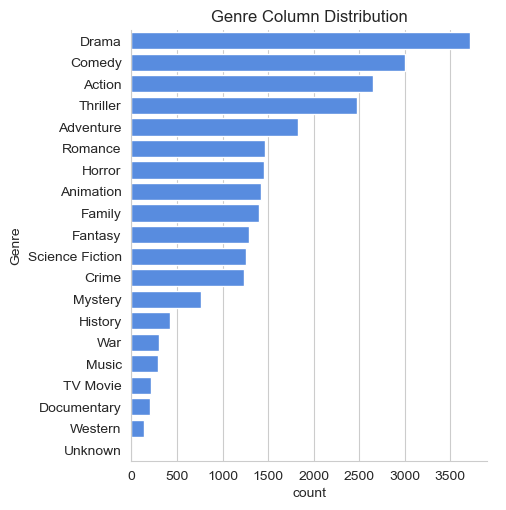

In [117]:
sns.catplot(y = 'Genre', data= df, kind='count', 
            order = df['Genre'].value_counts().index,
            color = '#4287f5')
plt.title('Genre Column Distribution')
plt.show()

# Which has highest vote in vote avg column?

In [101]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Science Fiction
3,2022,The Batman,3827.658,1151.0,popular,Crime
4,2022,The Batman,3827.658,1151.0,popular,Mystery


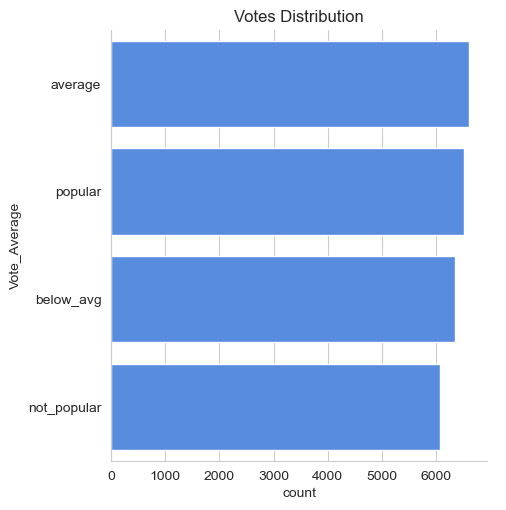

In [102]:
sns.catplot(y = 'Vote_Average', data=df, kind='count',
           order = df['Vote_Average'].value_counts().index,
            color = '#4287f5')
plt.title('Votes Distribution')
plt.show()

# What movie got the highest popularity? What is the genre?

In [103]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Science Fiction
3,2022,The Batman,3827.658,1151.0,popular,Crime
4,2022,The Batman,3827.658,1151.0,popular,Mystery


In [104]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Science Fiction


# What movie got the lowest popularity? What is the genre?

In [118]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152.0,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152.0,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152.0,average,History
25549,1984,Threads,13.354,186.0,popular,War
25550,1984,Threads,13.354,186.0,popular,Drama
25551,1984,Threads,13.354,186.0,popular,Science Fiction


# Which year has the most filmed movies?

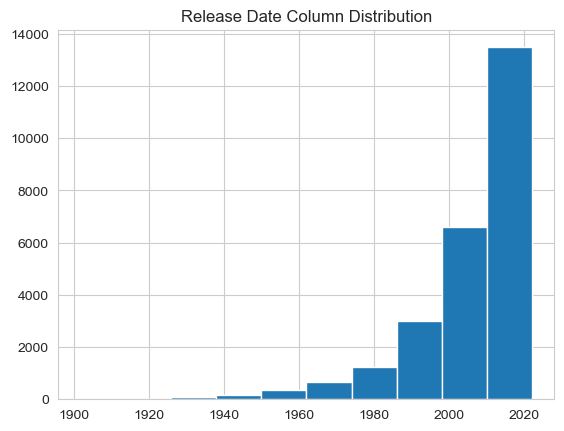

In [120]:
df['Release_Date'].hist()
plt.title('Release Date Column Distribution')
plt.show()

Conclusion:

Q1 What is the most frequent genre in the dataset?

Drama is the most frequent genre in the dataset and has appeared more than 14% of the times among 19 other genres.

Q2: Which genre has the highest vote?
We have 25.5% of our dataset with popular vote (6520 rows). Drama again gets the highest popularity among fans by being having more than 18.5% movies

Q3: Which movie got the highest popularity? What is the genre?

Spider Man: No way home has the highest popularity in our dataset and it has genre Action, Adventure and Science Fiction

Q4: Which movie got the Lowest popularity? What is the genre?

The united states thread has the lowest rate in our dataset and the genre is music, drama, war

Q5: Which year has the most filmed movies?

Year 2020 has the most filming rate in our dataset